In [13]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
from scipy.stats import bootstrap
import matplotlib 
%matplotlib inline

In [48]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins 2 and 3
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']
# spike-in 1 is GATC

# cell lines w/o spike-ins 2 and 3; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]

samples_3w = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 8)] + ['SK1_10'] + ['SK1_' + '{:0.0f}'.format(i) for i in range(12, 45)] # excluding 8 and 11
samples_3w_rag1 = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 8)] + ['SK1_10'] + ['SK1_' + '{:0.0f}'.format(i) for i in range(12, 25)] # excluding 8 and 11
samples_3w_f1 = ['SK1_' + '{:0.0f}'.format(i) for i in range(25, 45)] 

samples_2d = ['SK1_' + '{:0.0f}'.format(i) for i in [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]] + ['SK1_58_2', 'SK1_59_2', 'SK1_60_2']
samples_2d_rag1 = ['SK1_' + '{:0.0f}'.format(i) for i in [45, 46, 47, 48, 49, 50]]
samples_2d_f1 = ['SK1_' + '{:0.0f}'.format(i) for i in [51, 52, 53, 54, 55, 56, 57, 58, 59, 60]]

samples_in_vitro = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]

samples_transplant = ['SK1_' + '{:0.0f}'.format(i) for i in [94, 95, 99] + [103, 104, 107] + [111, 112, 114]]

samples_all = samples_pre_inj + samples_in_vitro + samples_2d + samples_3w + samples_transplant

In [15]:
# reading the cell line couts for each sample
n_reads = pd.read_csv('../Data/cell-line-level/cell_line_counts_by_sample.csv', index_col=0)

In [16]:
# converting into # of cells
n_cells = pd.DataFrame([[x] + [0 for y in samples_3w + samples_2d] for x in clIDs], columns = ['clID'] + samples_3w + samples_2d).set_index(['clID'])

n_cells_spiked_in = 50000

for i in samples_3w + samples_2d:
    for j in clIDs:
        # df.loc[row, column]
        n_cells.loc[j, i] = n_reads.loc[j, i] * n_cells_spiked_in / n_reads.loc['GATC', i]

$$
\text{We can show that the weighted average of the fraction of cell line $j$ is equal to} \quad \frac{\sum_i w_i \frac{r_{i,j}}{\sum_j r_{i,j}}}{\sum_i w_i} = \frac{\sum_i \frac{r_{i,j}}{R_i}N}{\sum_{i,j} \frac{r_{i,j}}{R_i}N} = \frac{\sum_i n_{i,j}}{\sum_{i,j} n_{i,j}} \quad \text{if the weightning function $w_i$ is the number of cells in sample $i$:} \quad w_i = \frac{\sum_{j}r_{i,j}}{R_i}N, \quad \text{where $R_i$ is the number of spike-in reads in sample $i$. We can also see that the result is independent of $N$.} 
$$

In [7]:
# trying to bootstrap again:
# bootstrapping fractions in 3w f1 and rag1 mice:

bootstrap_3w_f1 = {} # for each cell line: mean across actual mice and 0.95 confidence intervals

c = 0
for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    num = 0
    denom = 0
    for i in samples_3w_f1:
        num += n_reads.loc[j, i] # number of cells for j in a sample
        denom += sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]) # number of cells for all cell lines in a sample
                                                                                      # (summing over j)
    
    mean_j = num / denom # for each cell line, avg. cell fraction in each mouse 
                         # (summing num. and denom. over i)
    
    bootstrap_3w_f1[j] = [mean_j]
    
    # bootstrapping confidence intervals
    distr_j = []
    for n in range(10000): # how many times to sample
        
        # sampling mice with replacement
        mice = [samples_3w_f1[x] for x in np.random.choice(range(len(samples_3w_f1)), replace=True, size=len(samples_3w_f1))] 
    
        # calculaitng num. and denom. 
        num = 0
        denom = 0
        for i in mice:
            num += n_reads.loc[j, i] 
            denom += sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]) 

        mean_j = num / denom 
        distr_j.append(mean_j)
        
    #intervals_j = stats.t.interval(confidence=0.95, df=len(distr_j)-1, loc=np.mean(distr_j), scale=stats.sem(distr_j)) 
    bootstrap_3w_f1[j].append(np.percentile(distr_j, 2.5))
    bootstrap_3w_f1[j].append(np.percentile(distr_j, 97.5))
    
    c += 1
    print(str(c) + ' out of ' + str(len(clIDs) - 2) + ' done')
    


1 out of 33 done
2 out of 33 done
3 out of 33 done
4 out of 33 done
5 out of 33 done
6 out of 33 done
7 out of 33 done
8 out of 33 done
9 out of 33 done
10 out of 33 done
11 out of 33 done
12 out of 33 done
13 out of 33 done
14 out of 33 done
15 out of 33 done
16 out of 33 done
17 out of 33 done
18 out of 33 done
19 out of 33 done
20 out of 33 done
21 out of 33 done
22 out of 33 done
23 out of 33 done
24 out of 33 done
25 out of 33 done
26 out of 33 done
27 out of 33 done
28 out of 33 done
29 out of 33 done
30 out of 33 done
31 out of 33 done
32 out of 33 done
33 out of 33 done


In [8]:
# trying to bootstrap again:
# bootstrapping fractions in 3w rag1 and rag1 mice:

bootstrap_3w_rag1 = {} # for each cell line: mean across actual mice and 0.95 confidence intervals

c = 0
for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    num = 0
    denom = 0
    for i in samples_3w_rag1:
        num += n_reads.loc[j, i] # number of cells for j in a sample
        denom += sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]) # number of cells for all cell lines in a sample
                                                                                      # (summing over j)
    
    mean_j = num / denom # for each cell line, avg. cell fraction in each mouse 
                         # (summing num. and denom. over i)
    
    bootstrap_3w_rag1[j] = [mean_j]
    
    # bootstrapping confidence intervals
    distr_j = []
    for n in range(10000): # how many times to sample
        
        # sampling mice with replacement
        mice = [samples_3w_rag1[x] for x in np.random.choice(range(len(samples_3w_rag1)), replace=True, size=len(samples_3w_rag1))] 
    
        # calculaitng num. and denom. 
        num = 0
        denom = 0
        for i in mice:
            num += n_reads.loc[j, i] 
            denom += sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]) 

        mean_j = num / denom 
        distr_j.append(mean_j)
        
    #intervals_j = stats.t.interval(confidence=0.95, df=len(distr_j)-1, loc=np.mean(distr_j), scale=stats.sem(distr_j)) 
    bootstrap_3w_rag1[j].append(np.percentile(distr_j, 2.5))
    bootstrap_3w_rag1[j].append(np.percentile(distr_j, 97.5))
    
    c += 1
    print(str(c) + ' out of ' + str(len(clIDs) - 2) + ' done')


1 out of 33 done
2 out of 33 done
3 out of 33 done
4 out of 33 done
5 out of 33 done
6 out of 33 done
7 out of 33 done
8 out of 33 done
9 out of 33 done
10 out of 33 done
11 out of 33 done
12 out of 33 done
13 out of 33 done
14 out of 33 done
15 out of 33 done
16 out of 33 done
17 out of 33 done
18 out of 33 done
19 out of 33 done
20 out of 33 done
21 out of 33 done
22 out of 33 done
23 out of 33 done
24 out of 33 done
25 out of 33 done
26 out of 33 done
27 out of 33 done
28 out of 33 done
29 out of 33 done
30 out of 33 done
31 out of 33 done
32 out of 33 done
33 out of 33 done


In [15]:
# making the final table for Saswati:

table_3w = pd.DataFrame([[x] + [0, 0, 0, 0, 0, 0] for x in clIDs if x not in ['GATC', 'AACC']], # excludinfg spike in and mT4-2D 
                        columns = ['clID'] + ['3w F1 avg. frac. weighted by total # reads', 
                                              '3w F1 2.5 percentile', 
                                              '3w F1 97.5 percentile',
                                              '3w Rag1-/- avg. frac. weighted by total # reads', 
                                              '3w Rag1-/- 2.5 percentile', 
                                              '3w Rag1-/- 97.5 percentile']).set_index(['clID'])
                        
                                              

In [16]:
table_3w.head(0)

,3w F1 avg. frac. weighted by total # reads,3w F1 2.5 percentile,3w F1 97.5 percentile,3w Rag1-/- avg. frac. weighted by total # reads,3w Rag1-/- 2.5 percentile,3w Rag1-/- 97.5 percentile
clID,,,,,,


In [17]:
for j in clIDs:
    if j in ['GATC', 'AACC']:
        continue
        
    table_3w.loc[j, '3w F1 avg. frac. weighted by total # reads'] = bootstrap_3w_f1[j][0]
    table_3w.loc[j, '3w F1 2.5 percentile'] = bootstrap_3w_f1[j][1]
    table_3w.loc[j, '3w F1 97.5 percentile'] = bootstrap_3w_f1[j][2]
        
    table_3w.loc[j, '3w Rag1-/- avg. frac. weighted by total # reads'] = bootstrap_3w_rag1[j][0]
    table_3w.loc[j, '3w Rag1-/- 2.5 percentile'] = bootstrap_3w_rag1[j][1]
    table_3w.loc[j, '3w Rag1-/- 97.5 percentile'] = bootstrap_3w_rag1[j][2]

In [18]:
table_3w

,3w F1 avg. frac. weighted by total # reads,3w F1 2.5 percentile,3w F1 97.5 percentile,3w Rag1-/- avg. frac. weighted by total # reads,3w Rag1-/- 2.5 percentile,3w Rag1-/- 97.5 percentile
clID,,,,,,
AAGG,1.677926e-02,0.013430,0.022279,1.168263e-02,0.008924,1.462380e-02
ACAC,1.227045e-02,0.003835,0.019293,2.069763e-02,0.014713,2.759604e-02
ACCT,1.004186e-01,0.037917,0.176472,4.509484e-02,0.024905,8.185269e-02
ACGA,2.377155e-02,0.016758,0.029813,1.420492e-02,0.011272,1.653079e-02
ACTG,1.800205e-02,0.010211,0.025387,2.860100e-02,0.017558,4.428802e-02
AGAG,9.484755e-02,0.053332,0.147721,4.804814e-02,0.033323,7.056883e-02
AGCA,7.145384e-07,0.000000,0.000003,1.742426e-08,0.000000,6.710125e-08
AGGT,1.525722e-02,0.004652,0.026616,1.529864e-02,0.006487,2.856300e-02
AGTC,8.362350e-02,0.052957,0.128246,2.023739e-02,0.009510,3.157954e-02


In [19]:
# saving the output: 
#table_3w.to_csv('../Data/cell-line-level/3w_avg_cell_line_fracs_bootstrapped.csv')  
        

In [58]:
n_reads.loc[j, 'SK1_61'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_61'])

978896

In [17]:
# ordering by the highest avg. count at the last time point relative to t=1 in the in vitro data
# do not have spike-ins
clIDs_ordered = ['AGGT', 'AGCA', 'CTTC', 'AGTC', 'AACC', 'ATCG', 'GAAG', 'CACT', 'ACCT', 'CCTT', 'CATG', 'GGAA', 'ACAC', 'GTTG', 'AGAG', 'TTGG', 'TCCA', 'CTGT', 'TTCC', 'CAGA', 'GCAT', 'CGTA', 'GGTT', 'ACGA', 'AAGG', 'GTAC', 'CGAT', 'GCTA', 'CAAC', 'TGAC', 'ATGC', 'ACTG', 'GTGA', 'CCAA']

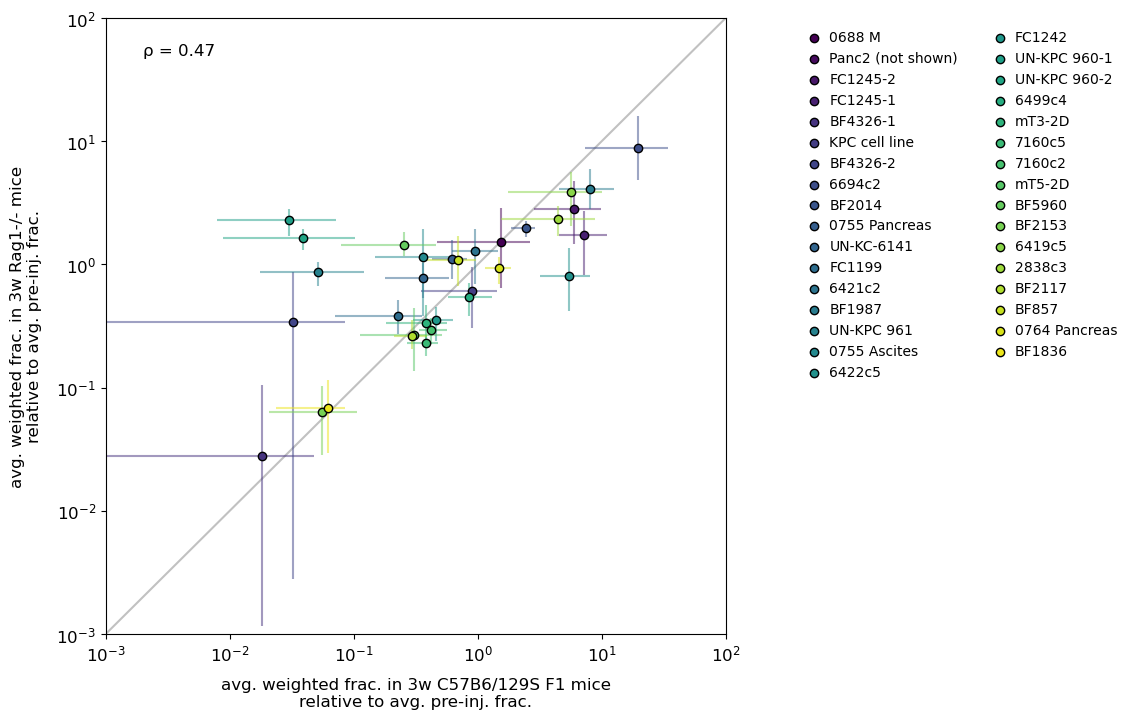

In [69]:
plt.figure(figsize=(8, 8))

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))


xs = []; ys = []
for count, j in enumerate(clIDs_ordered):
    if j in ['AACC']:
        continue
        
    if clID_dict[j] == 'Panc2':
        label = 'Panc2 (not shown)' # cutting the axis limits
    else:
        label = clID_dict[j].replace('_', ' ')
    
    # calculating the normalizing factor as the avg. pre-injection fraction (excluding spike-ins but including mT4-2D)
    norm = np.mean([n_reads.loc[j, 'SK1_61'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_61']),
            n_reads.loc[j, 'SK1_62'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_62']),
            n_reads.loc[j, 'SK1_62'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_63'])])
        
    x = table_3w.loc[j, '3w F1 avg. frac. weighted by total # reads'] / norm
    y = table_3w.loc[j, '3w Rag1-/- avg. frac. weighted by total # reads'] / norm
    
    x_err = [[x - table_3w.loc[j, '3w F1 2.5 percentile'] / norm], [table_3w.loc[j, '3w F1 97.5 percentile'] / norm - x]]
    y_err = [[y - table_3w.loc[j, '3w Rag1-/- 2.5 percentile'] / norm], [table_3w.loc[j, '3w Rag1-/- 97.5 percentile'] / norm - y]]
        
    plt.scatter(x, y, color=viridis.to_rgba(count), edgecolor='black', alpha=1, label=label, zorder=2)
    
    plt.errorbar(x, y, xerr=x_err, yerr=y_err, color=viridis.to_rgba(count), alpha=0.5, zorder=1)
            
    xs.append(table_3w.loc[j, '3w F1 avg. frac. weighted by total # reads'])
    ys.append(table_3w.loc[j, '3w Rag1-/- avg. frac. weighted by total # reads'])
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. weighted frac. in 3w C57B6/129S F1 mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. weighted frac. in 3w Rag1-/- mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/avg_read_frac_per_cell_line_norm_0.95ci.png', dpi=300, bbox_inches='tight')

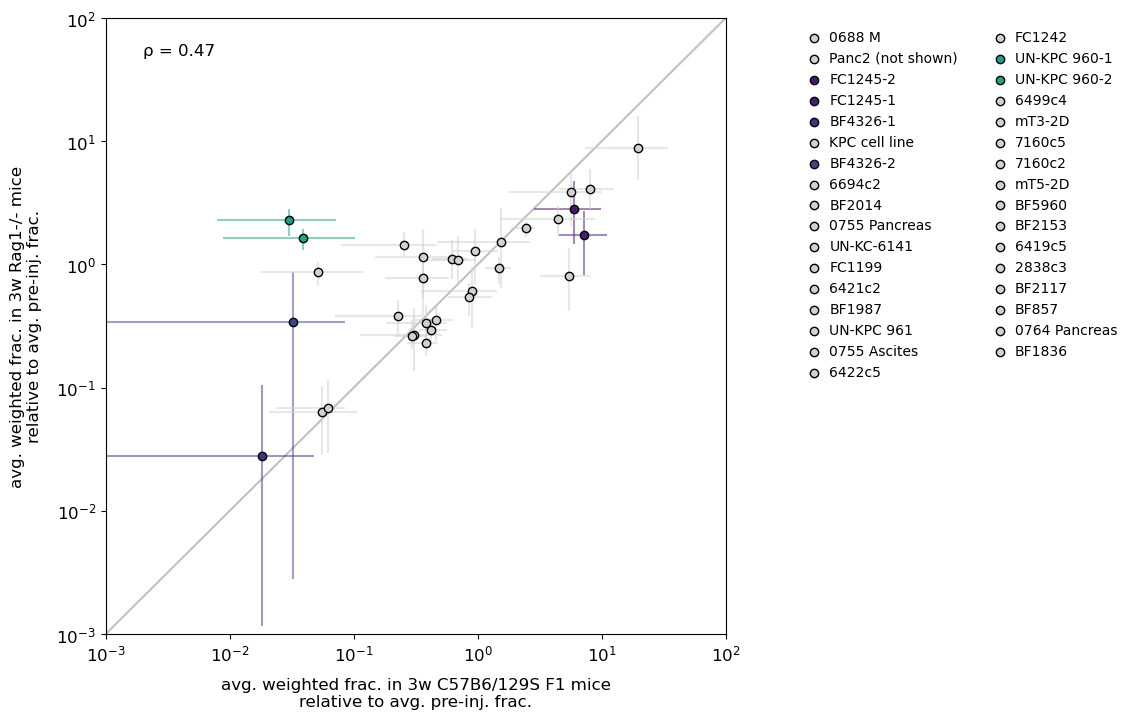

In [70]:
plt.figure(figsize=(8, 8))

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))


xs = []; ys = []
for count, j in enumerate(clIDs_ordered):
    if j in ['AACC']:
        continue
        
    if clID_dict[j] == 'Panc2':
        label = 'Panc2 (not shown)' # cutting the axis limits
    else:
        label = clID_dict[j].replace('_', ' ')
        
    if clID_dict[j] in ['FC1245-1', 'FC1245-2', 'BF4326-1', 'BF4326-2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        c = viridis.to_rgba(count)
        z = 3
    else:
        c = '#d1d1d1'
        z = 2
        
    # calculating the normalizing factor as the avg. pre-injection fraction (excluding spike-ins but including mT4-2D)
    norm = np.mean([n_reads.loc[j, 'SK1_61'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_61']),
            n_reads.loc[j, 'SK1_62'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_62']),
            n_reads.loc[j, 'SK1_62'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_63'])])
        
    x = table_3w.loc[j, '3w F1 avg. frac. weighted by total # reads'] / norm
    y = table_3w.loc[j, '3w Rag1-/- avg. frac. weighted by total # reads'] / norm
    
    x_err = [[x - table_3w.loc[j, '3w F1 2.5 percentile'] / norm], [table_3w.loc[j, '3w F1 97.5 percentile'] / norm - x]]
    y_err = [[y - table_3w.loc[j, '3w Rag1-/- 2.5 percentile'] / norm], [table_3w.loc[j, '3w Rag1-/- 97.5 percentile'] / norm - y]]
        
    plt.scatter(x, y, color=c, edgecolor='black', alpha=1, label=label, zorder=2)
    
    plt.errorbar(x, y, xerr=x_err, yerr=y_err, color=c, alpha=0.5, zorder=1)
            
    xs.append(table_3w.loc[j, '3w F1 avg. frac. weighted by total # reads'])
    ys.append(table_3w.loc[j, '3w Rag1-/- avg. frac. weighted by total # reads'])
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. weighted frac. in 3w C57B6/129S F1 mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. weighted frac. in 3w Rag1-/- mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/avg_read_frac_per_cell_line_norm_0.95ci_grey.png', dpi=300, bbox_inches='tight')

In [62]:
# opening the table:

avgs = pd.read_csv('../Data/cell-line-level/3w_avg_cell_line_fracs_bootstrapped.csv', index_col=0)

In [63]:
# need to do: add avg pre-inj fractions in the first column + add weighted means for 2 d + stds 

In [64]:
avgs.insert(0, 'avg. pre-inj. frac.', [0 for i in range(len(avgs))])

for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
    
    # calculating the normalizing factor as the avg. pre-injection fraction (excluding spike-ins but including mT4-2D)
    norm = np.mean([n_reads.loc[j, 'SK1_61'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_61']),
           n_reads.loc[j, 'SK1_62'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_62']),
           n_reads.loc[j, 'SK1_62'] / sum(n_reads.loc[[x for x in clIDs if x != 'AACC'], 'SK1_63'])])
    
    avgs.loc[j, 'avg. pre-inj. frac.'] = norm 

In [65]:
# adding other weighted means and errors
avgs.insert(7, '2d F1 avg. frac. weighted by total # reads', [0 for i in range(len(avgs))])
avgs.insert(8, '2d F1 weighted unbiased standard deviation', [0 for i in range(len(avgs))])
avgs.insert(9, '2d Rag1-/- avg. frac. weighted by total # reads', [0 for i in range(len(avgs))])
avgs.insert(10, '2d Rag1-/- weighted unbiased standard deviation', [0 for i in range(len(avgs))])

In [66]:
# calculating weighted averages first;
# treating Rag1-/- samples as different mice which is probably wrong 

for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    num = 0
    denom = 0
    for i in samples_2d_f1:
        num += n_reads.loc[j, i] # number of cells for j in a sample
        denom += sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]) # number of cells for all cell lines in a sample
                                                                                      # (summing over j)
    
    mean_j = num / denom # for each cell line, avg. cell fraction in each mouse 
                         # (summing num. and denom. over i)
        
    avgs.loc[j, '2d F1 avg. frac. weighted by total # reads'] = mean_j
    
    
for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    num = 0
    denom = 0
    for i in samples_2d_rag1:
        num += n_reads.loc[j, i] # number of cells for j in a sample
        denom += sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]) # number of cells for all cell lines in a sample
                                                                                      # (summing over j)
    
    mean_j = num / denom # for each cell line, avg. cell fraction in each mouse 
                         # (summing num. and denom. over i)
        
    avgs.loc[j, '2d Rag1-/- avg. frac. weighted by total # reads'] = mean_j

In [ ]:
# np.sqrt(np.cov(values, aweights=weights))

$$
\text{Calculating the weighted standard deviation of the fraction of cell line $j$ as} \quad \sqrt{\frac{\sum_i w_i \left(\frac{r_{i,j}}{\sum_j r_{i,j}} - \bar{f_w}\right)^2}{\frac{M-1}{M}\sum_i w_i}}, \quad \text{where the weightning function $w_i$ is the number of cells in sample $i$:} \quad w_i = \frac{\sum_{j}r_{i,j}}{R_i}N, \quad \text{where $R_i$ is the number of spike-in reads in sample $i$, $N$ is the number of spiked-in cells, 
$M$ is the number of samples with non-zero values and $\bar{f_w}$ is the weighted average from above.} 
$$

In [78]:
# calculating weighted stds 
# treating Rag1-/- samples as different mice which is probably wrong 

for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    num = 0
    denom = 0
    m = 0 # number of non-zero weights for bias correction
    for i in samples_2d_f1:
        
        # computing the w_i for sample i first:
        w_i = sum(n_cells.loc[:, i])
        
        # calculating the frac. of cells in this sample:
        f_ij = n_reads.loc[j, i] / sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i])
        
        num += w_i * (f_ij - avgs.loc[j, '2d F1 avg. frac. weighted by total # reads'])**2
        
        denom += w_i
        
        if w_i != 0:
            m += 1
        
    std_j = math.sqrt(m * num / ((m - 1) * denom))
        
    avgs.loc[j, '2d F1 weighted unbiased standard deviation'] = std_j
    
    
for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    num = 0
    denom = 0
    m = 0 # number of non-zero weights for bias correction
    for i in samples_2d_rag1:
        
        # computing the w_i for sample i first:
        w_i = sum(n_cells.loc[:, i])
        
        # calculating the frac. of cells in this sample:
        f_ij = n_reads.loc[j, i] / sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i])
        
        num += w_i * (f_ij - avgs.loc[j, '2d Rag1-/- avg. frac. weighted by total # reads'])**2
        
        denom += w_i
        
        if w_i != 0:
            m += 1
        
    std_j = math.sqrt(m * num / ((m - 1) * denom))
        
    avgs.loc[j, '2d Rag1-/- weighted unbiased standard deviation'] = std_j
    
    


In [79]:
avgs

,avg. pre-inj. frac.,3w F1 avg. frac. weighted by total # reads,3w F1 2.5 percentile,3w F1 97.5 percentile,3w Rag1-/- avg. frac. weighted by total # reads,3w Rag1-/- 2.5 percentile,3w Rag1-/- 97.5 percentile,2d F1 avg. frac. weighted by total # reads,2d F1 weighted unbiased standard deviation,2d Rag1-/- avg. frac. weighted by total # reads,2d Rag1-/- weighted unbiased standard deviation
clID,,,,,,,,,,,
AAGG,0.03971601,0.01677926,0.01343028,0.02227947,0.01168263,0.00892384,0.01462380,0.06430505,0.01287900,0.07160879,0.03458878
ACAC,0.05378329,0.01227045,0.00383531,0.01929315,0.02069763,0.01471288,0.02759604,0.02417046,0.00220682,0.01923784,0.00391699
ACCT,0.00513495,0.10041862,0.03791698,0.17647170,0.04509484,0.02490502,0.08185269,0.00736090,0.00072507,0.00724103,0.00286777
ACGA,0.06180994,0.02377155,0.01675803,0.02981338,0.01420492,0.01127203,0.01653079,0.07320519,0.01179841,0.03058430,0.00630707
ACTG,0.02608735,0.01800205,0.01021090,0.02538734,0.02860100,0.01755776,0.04428802,0.02851693,0.00207104,0.01295794,0.00627431
AGAG,0.01178666,0.09484755,0.05333164,0.14772076,0.04804814,0.03332322,0.07056883,0.01945393,0.01439575,0.02694111,0.01610936
AGCA,0.05392612,0.00000071,0.00000000,0.00000281,0.00000002,0.00000000,0.00000007,0.00168774,0.00059125,0.00039526,0.00035337
AGGT,0.00997412,0.01525722,0.00465175,0.02661582,0.01529864,0.00648745,0.02856300,0.01249362,0.00087244,0.00853364,0.00254083
AGTC,0.01158217,0.08362350,0.05295667,0.12824568,0.02023739,0.00951017,0.03157954,0.00998222,0.00167133,0.04403642,0.03712981


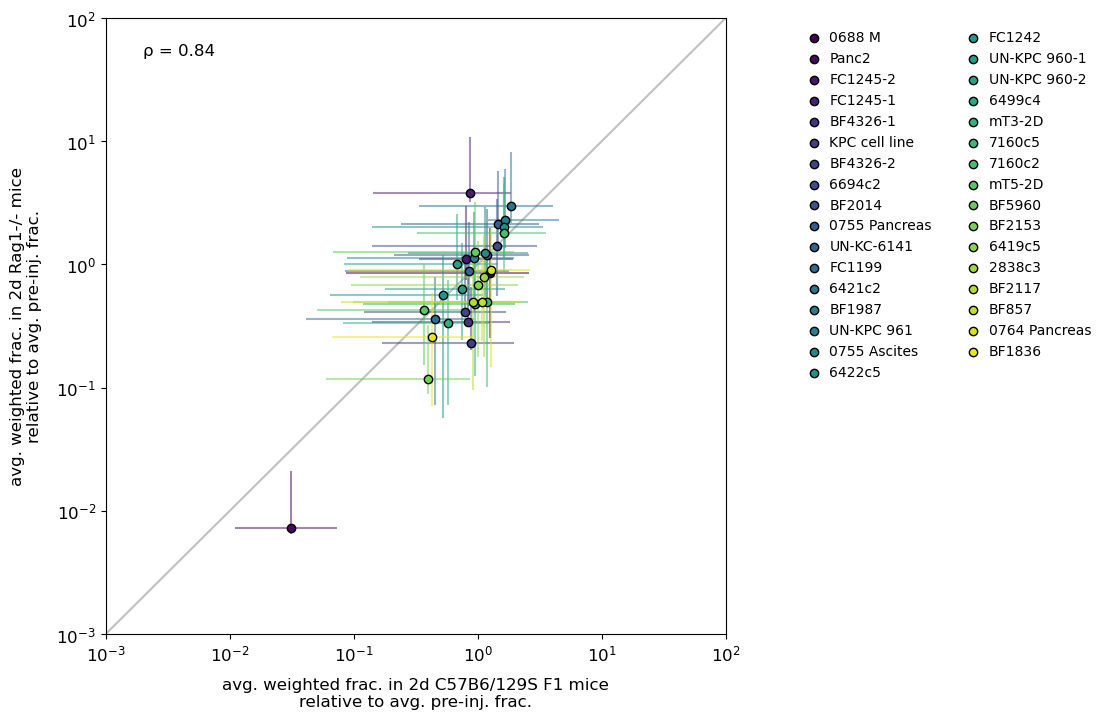

In [96]:
plt.figure(figsize=(8, 8))

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))


xs = []; ys = []
for count, j in enumerate(clIDs_ordered):
    if j in ['AACC']:
        continue
        
    if clID_dict[j] == 'Panc2':
        label = 'Panc2'
    else:
        label = clID_dict[j].replace('_', ' ')
    
    norm = avgs.loc[j, 'avg. pre-inj. frac.']
        
    x = avgs.loc[j, '2d F1 avg. frac. weighted by total # reads'] / norm
    y = avgs.loc[j, '2d Rag1-/- avg. frac. weighted by total # reads'] / norm
    
    x_err = [[x - avgs.loc[j, '2d F1 weighted unbiased standard deviation'] / norm], [x + avgs.loc[j, '2d F1 weighted unbiased standard deviation'] / norm]]
    y_err = [[y - avgs.loc[j, '2d Rag1-/- weighted unbiased standard deviation'] / norm], [y + avgs.loc[j, '2d Rag1-/- weighted unbiased standard deviation'] / norm]]
        
    plt.scatter(x, y, color=viridis.to_rgba(count), edgecolor='black', alpha=1, label=label, zorder=2)
    
    plt.errorbar(x, y, xerr=x_err, yerr=y_err, color=viridis.to_rgba(count), alpha=0.5, zorder=1)
            
    # plt.text(x, y, label)    
        
    xs.append(avgs.loc[j, '2d F1 avg. frac. weighted by total # reads'])
    ys.append(avgs.loc[j, '2d Rag1-/- avg. frac. weighted by total # reads'])
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. weighted frac. in 2d C57B6/129S F1 mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. weighted frac. in 2d Rag1-/- mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

# plt.savefig('../Data/cell-line-level/2d_avg_read_frac_per_cell_line_norm_std.png', dpi=300, bbox_inches='tight')

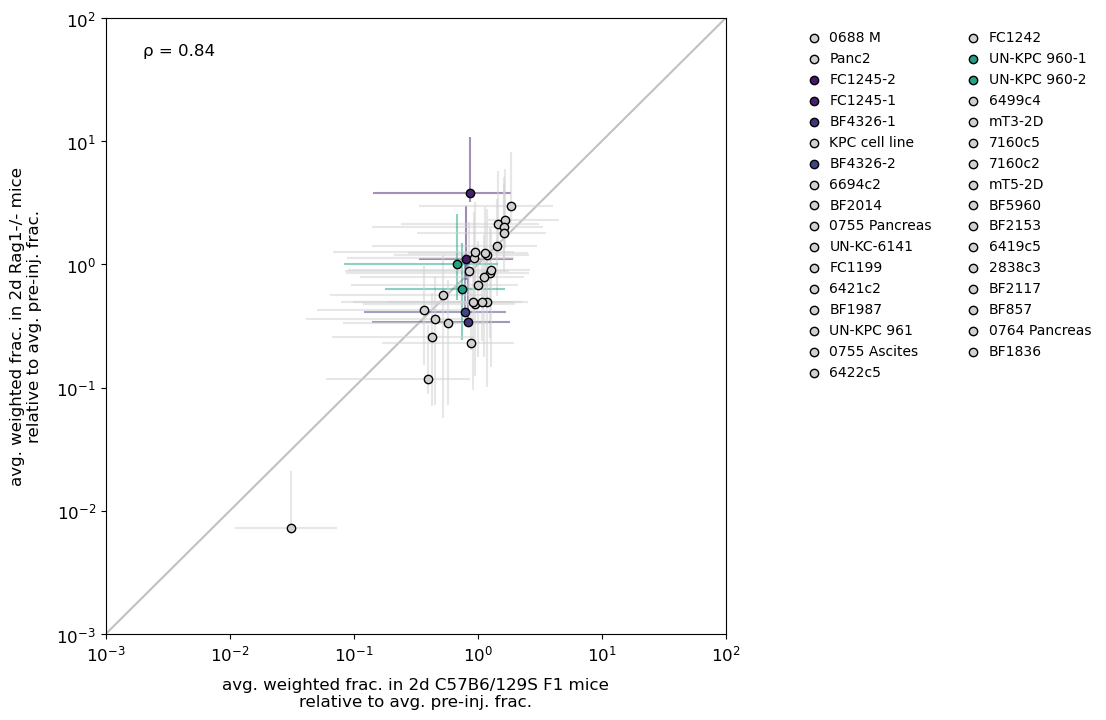

In [94]:
plt.figure(figsize=(8, 8))

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))


xs = []; ys = []
for count, j in enumerate(clIDs_ordered):
    if j in ['AACC']:
        continue
        
    if clID_dict[j] == 'Panc2':
        label = 'Panc2'
    else:
        label = clID_dict[j].replace('_', ' ')
        
    if clID_dict[j] in ['FC1245-1', 'FC1245-2', 'BF4326-1', 'BF4326-2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        c = viridis.to_rgba(count)
        z = 3
    else:
        c = '#d1d1d1'
        z = 2
    
    norm = avgs.loc[j, 'avg. pre-inj. frac.']
        
    x = avgs.loc[j, '2d F1 avg. frac. weighted by total # reads'] / norm
    y = avgs.loc[j, '2d Rag1-/- avg. frac. weighted by total # reads'] / norm
    
    x_err = [[x - avgs.loc[j, '2d F1 weighted unbiased standard deviation'] / norm], [x + avgs.loc[j, '2d F1 weighted unbiased standard deviation'] / norm]]
    y_err = [[y - avgs.loc[j, '2d Rag1-/- weighted unbiased standard deviation'] / norm], [y + avgs.loc[j, '2d Rag1-/- weighted unbiased standard deviation'] / norm]]
        
    plt.scatter(x, y, color=c, edgecolor='black', alpha=1, label=label, zorder=2)
    
    plt.errorbar(x, y, xerr=x_err, yerr=y_err, color=c, alpha=0.5, zorder=1)
            
    # plt.text(x, y, label)    
        
    xs.append(avgs.loc[j, '2d F1 avg. frac. weighted by total # reads'])
    ys.append(avgs.loc[j, '2d Rag1-/- avg. frac. weighted by total # reads'])
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. weighted frac. in 2d C57B6/129S F1 mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. weighted frac. in 2d Rag1-/- mice\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/2d_avg_read_frac_per_cell_line_norm_std_replicates.png', dpi=300, bbox_inches='tight')

In [97]:
# saving the output:
# avgs.to_csv('../Data/cell-line-level/3w_2d_avg_cell_line_fracs_error_bars.csv')  